In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("/content/covid19_drugs_dataset.xlsx")

In [3]:
print(df.shape)

print(df.head())

(661, 1771)
         cid                                    Compound Name  \
0   10074640                                        Masitinib   
1  101087010  (2Z,4E)-4-Hydroxy-6-oxo-2,4-octadienedioic acid   
2     101543                                 3'-Uridylic acid   
3       1023                              Pyrophosphoric acid   
4   10462221                        3-hydroxybut-3-enoic Acid   

                                 Class  \
0  Benzene and substituted derivatives   
1                                  NaN   
2         Ribonucleoside 3'-phosphates   
3        Non-metal oxoanionic compound   
4                                  NaN   

                                Superclass         Solubility  \
0                             \nBenzenoids  Sparingly soluble   
1                                      NaN     Freely soluble   
2  Nucleosides, nucleotides, and analogues       Very soluble   
3          Homogeneous non-metal compounds       Very soluble   
4                  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Columns: 1771 entries, cid to annotation_V - Various > V03 - All other therapeutic products > V03A - All other therapeutic products > V03AB - Antidotes|COVID-19|COVID19|Coronavirus|Corona-virus|SARS|SARS2|SARS-CoV|SARS-CoV-2|COVID info from PDB, Protein Data Bank
dtypes: float64(46), int64(1712), object(13)
memory usage: 8.9+ MB


In [5]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

,0
pCHEMBL,578
meshheadings,451
Superclass,40
Class,40
octanol/water partition coefficients (xlogp),22
ADME Efficiency Index,22
Hydrophobic_Hydrophilic_Balance_Index,22
Lipophilic Ligand Effeciency (LLE),22
IUPAC name,2
canonical smiles,1


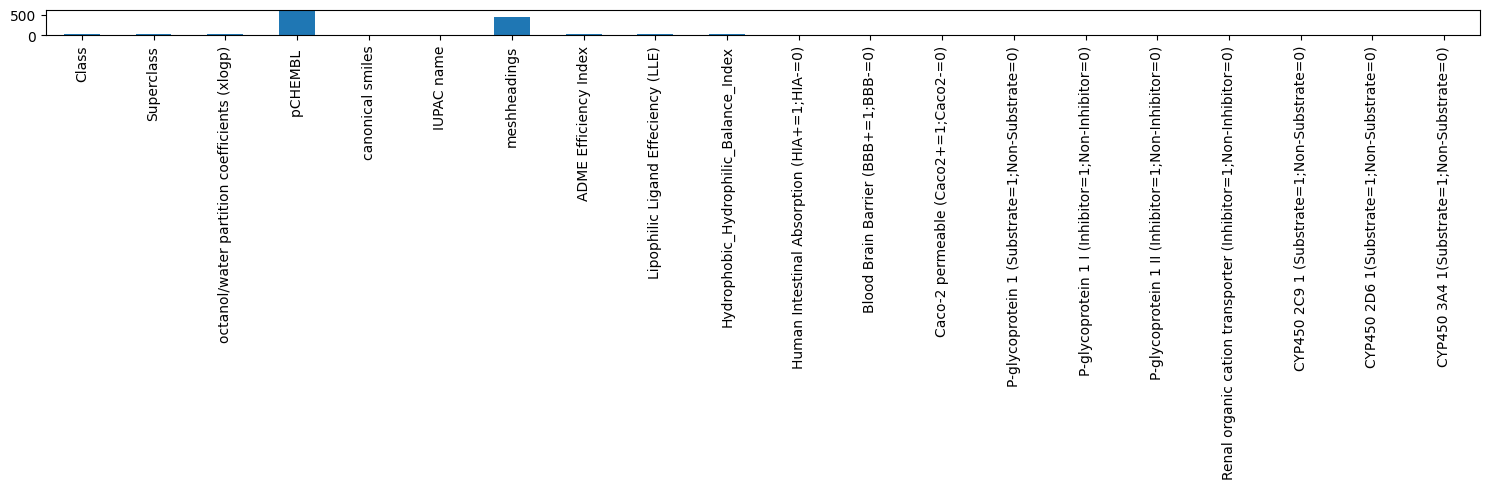

In [6]:
plt.figure(figsize=(15,5))

missing.head(20).plot(kind="bar")

plt.tight_layout()

plt.show()

In [8]:
import os

os.makedirs('images', exist_ok=True)
plt.savefig("images/missing_values.png")

<Figure size 640x480 with 0 Axes>

In [9]:
completeness = (df.notnull().mean()*100)

summary = pd.DataFrame({

"Completeness":completeness,

"Missing":df.isnull().sum(),

"Unique":df.nunique(),

"Datatype":df.dtypes

})

summary.head()

,Completeness,Missing,Unique,Datatype
cid,100.000000,0,661,object
Compound Name,100.000000,0,661,object
Class,93.948563,40,130,object
Superclass,93.948563,40,33,object
Solubility,100.000000,0,7,object


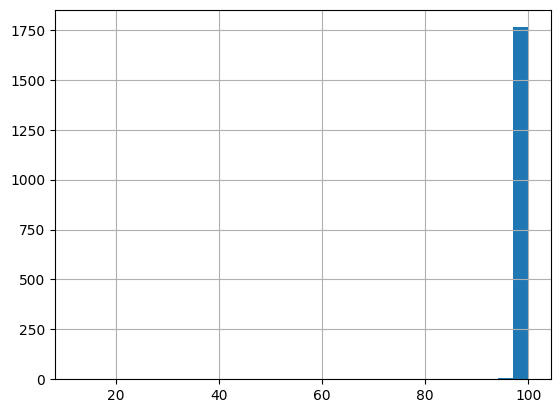

In [10]:
summary["Completeness"].hist(bins=30)

plt.savefig("images/completeness_histogram.png")

In [11]:
keywords=[
"gene",
"protein",
"pathway",
"target",
"disease",
"drug",
"enzyme",
"receptor",
"toxicity",
"bioactivity"
]

bio_features={}

for word in keywords:

    cols=[c for c in df.columns if word in str(c).lower()]

    bio_features[word]=cols

bio_features

{'gene': ['Aldosterone from Steroidogenesis',
  'Antiviral mechanism by IFN-stimulated genes',
  'CDO in myogenesis',
  "Deregulated CDK5 triggers multiple neurodegenerative pathways in Alzheimer's disease models",
  'Epigenetic regulation of gene expression',
  'Estrogen-dependent gene expression',
  'Gene Silencing by RNA',
  'Gene expression (Transcription)',
  'Generation of second messenger molecules',
  'Generic Transcription Pathway',
  'Hedgehog ligand biogenesis',
  'Lysosome Vesicle Biogenesis',
  'MicroRNA (miRNA) biogenesis',
  'Mitochondrial biogenesis',
  'Myogenesis',
  'Negative epigenetic regulation of rRNA expression',
  'Neurodegeneration with brain iron accumulation (NBIA) subtypes pathway',
  'Neurodegenerative Diseases',
  'Oncogene Induced Senescence',
  'Organelle biogenesis and maintenance',
  'PERK regulates gene expression',
  'PIWI-interacting RNA (piRNA) biogenesis',
  'Positive epigenetic regulation of rRNA expression',
  'RNA polymerase II transcribes snR

In [13]:
import os
os.makedirs('results', exist_ok=True)
summary.to_csv("results/dataset_profile.csv")